<a href="https://colab.research.google.com/github/Phalguni-dhabale/MV-LAB/blob/main/MV_PRAC_7_D3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
uploaded = files.upload()

video_filename = next(iter(uploaded))
print(f'Uploaded file: {video_filename}')

Saving 156157-811878168.mp4 to 156157-811878168.mp4
Uploaded file: 156157-811878168.mp4


Video Properties:
  - Filename: 156157-811878168.mp4
  - FPS: 29.97002997002997
  - Dimensions: 2160x3840
  - Total Frames: 1005


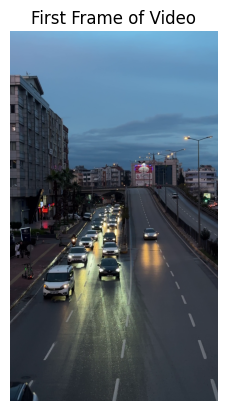

In [7]:
cap = cv2.VideoCapture(video_filename)

if not cap.isOpened():
    print("Error: Could not open video file.")
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"Video Properties:")
    print(f"  - Filename: {video_filename}")
    print(f"  - FPS: {fps}")
    print(f"  - Dimensions: {width}x{height}")
    print(f"  - Total Frames: {frame_count}")


    ret, frame = cap.read()
    if ret:
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title('First Frame of Video')
        plt.axis('off')
        plt.show()
    else:
        print("Could not read the first frame.")

    cap.release()

In [8]:

cap = cv2.VideoCapture(video_filename)

if not cap.isOpened():
    print("Error: Could not open video file for motion detection.")
else:

    ret, frame1 = cap.read()
    if not ret:
        print("Error: Could not read the first frame for motion detection.")
        cap.release()
    else:

        gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
        gray1 = cv2.GaussianBlur(gray1, (21, 21), 0)


        while True:
            ret, frame2 = cap.read()
            if not ret:
                break
            gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
            gray2 = cv2.GaussianBlur(gray2, (21, 21), 0)


            frame_diff = cv2.absdiff(gray1, gray2)


            _, thresh = cv2.threshold(frame_diff, 25, 255, cv2.THRESH_BINARY)


            thresh = cv2.dilate(thresh, None, iterations=2)


            contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


            for contour in contours:
                if cv2.contourArea(contour) < 500:
                (x, y, w, h) = cv2.boundingRect(contour)
                cv2.rectangle(frame2, (x, y), (x + w, y + h), (0, 255, 0), 2)


            if cap.get(cv2.CAP_PROP_POS_FRAMES) % 30 == 0:
                display(plt.imshow(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)))
                plt.title(f'Frame with Motion Detection (Frame {int(cap.get(cv2.CAP_PROP_POS_FRAMES))})')
                plt.axis('off')
                plt.show()
                clear_output(wait=True)


            gray1 = gray2

        cap.release()
        print("Motion detection complete.")

Motion detection complete.


In [9]:
cap = cv2.VideoCapture(video_filename)

if not cap.isOpened():
    print("Error: Could not open video file for optical flow.")
else:

    feature_params = dict( maxCorners = 100,
                           qualityLevel = 0.3,
                           minDistance = 7,
                           blockSize = 7 )

    lk_params = dict( winSize  = (15,15),
                      maxLevel = 2,
                      criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

    color = np.random.randint(0, 255, (100, 3))


    ret, old_frame = cap.read()
    if not ret:
        print("Error: Could not read the first frame for optical flow.")
        cap.release()
    else:
        old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
        p0 = cv2.goodFeaturesToTrack(old_gray, mask = None, **feature_params)


        mask = np.zeros_like(old_frame)

        frame_idx = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)


            p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)

            if p1 is not None:
                good_new = p1[st==1]
                good_old = p0[st==1]


                for i, (new, old) in enumerate(zip(good_new, good_old)):
                    a, b = new.ravel()
                    c, d = old.ravel()
                    mask = cv2.line(mask, (int(a), int(b)), (int(c), int(d)), color[i].tolist(), 2)
                    frame = cv2.circle(frame, (int(a), int(b)), 5, color[i].tolist(), -1)
                img = cv2.add(frame, mask)


                if frame_idx % 30 == 0:
                    display(plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)))
                    plt.title(f'Frame with Optical Flow (Frame {frame_idx})')
                    plt.axis('off')
                    plt.show()
                    clear_output(wait=True)


                old_gray = frame_gray.copy()
                p0 = good_new.reshape(-1, 1, 2)

            frame_idx += 1

        cap.release()
        print("Optical flow calculation complete.")

Optical flow calculation complete.


In [ ]:
cap = cv2.VideoCapture(video_filename)

if not cap.isOpened():
    print("Error: Could not open video file for background subtraction.")
else:

    fgbg = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=16, detectShadows=True)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        fgmask = fgbg.apply(frame)


        fgmask = cv2.morphologyEx(fgmask, cv2.MORPH_OPEN, kernel)

        fgmask = cv2.morphologyEx(fgmask, cv2.MORPH_CLOSE, kernel)


        contours, _ = cv2.findContours(fgmask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        processed_frame = frame.copy()
        for contour in contours:
            if cv2.contourArea(contour) < 1000: # Filter out small contours (noise or insignificant movement)
                continue
            (x, y, w, h) = cv2.boundingRect(contour)
            cv2.rectangle(processed_frame, (x, y), (x + w, y + h), (0, 255, 255), 2) # Yellow rectangle


        if frame_idx % 30 == 0:
            display(plt.imshow(cv2.cvtColor(processed_frame, cv2.COLOR_BGR2RGB)))
            plt.title(f'Frame with Background Subtraction (Frame {frame_idx})')
            plt.axis('off')
            plt.show()
            clear_output(wait=True)



        frame_idx += 1

    cap.release()
    print("Background subtraction complete.")